# ResNet TOV Emulator to predict Mass, Radius and Tidal Deformability of a Neutron Strar from a PP EOS - Final

### <div style= 'color: orange'> Import all the required modules

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import torch
import itertools
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from scipy.interpolate import interp1d
from tqdm import trange
from numba import jit
from tracemalloc import start
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from TOV2 import tov_vectorized
%matplotlib widget

### <div style= 'color: orange'> Global constants and unit conversion factors

In [2]:
msun=147660                 # Solar mass in cm given by the formula G*M_sun/c^2

c=2.9979e10                 # speed of light in cm/s (CGS)
G=6.67408e-8                # gravitational constant in cm^3/gm/s^2 (CGS)

dkm = 1.3234e-06            # conversion of MeV/fm^3 to km^-2
dcgs = 1.78e12              # factor to convert from MeV/fm^3 to gm/cm^3
conv = 8.2601e-40           # dyn/cm^2 to km^-2
cgs1=1.7827e+12             # MeV/fm3 to gms/cm3
cgs2=1.6022e+33             # MeV/fm3 to dyne/cm2

### <div style= 'color: orange'>4 Piecewise-polytrope low-density (crust) parameters

In [3]:
# Low density Polytropic exponents
GammaL_1 = 1.35692
GammaL_2 = 0.62223
GammaL_3 = 1.28733
GammaL_4 = 1.58425

# Low density Polytropic constants
KL_1 = 3.99874e-8 # * pow(Msun/Length**3, GammaL_1-1)
KL_2 = 5.32697e+1 # * pow(Msun/Length**3, GammaL_2-1)
KL_3 = 1.06186e-6 # * pow(Msun/Length**3, GammaL_3-1)
KL_4 = 6.80110e-9 # * pow(Msun/Length**3, GammaL_4-1)
# notice a missing c^2 in Ki values in Table II of Read et al. 2009

# Densities at the boundaries of the low density piecewise polytropes
rhoL_1 = 2.62789e12
rhoL_2 = 3.78358e11
rhoL_3 = 2.44034e7
rhoL_4 = 0.0

# Pressures at the boundaries of the low density piecewise polytropes
pL_1 = KL_1*rhoL_1**GammaL_1
pL_2 = KL_2*rhoL_2**GammaL_2
pL_3 = KL_3*rhoL_3**GammaL_3
pL_4 = 0.0

# The exact numbers are taken from a particular crust model/table.

### <div style= 'color: orange'> Low density Energy density, α, and Break densities

In [4]:
# Compute the offsets specific internal energy (epsL_i) and alphaL_i at the 
# boundaries
# The general form used: ε(ρ)=(1+α)ρ+K/(Γ−1)ρ^Γ. 
# Solving for alpha ensures matching across boundaries.
# Energy density needs an additive offset to enforce continuity.

epsL_4 = 0.0
alphaL_4 = 0.0
epsL_3 = (1+alphaL_4)*rhoL_3 + KL_4/(GammaL_4 - 1.)*pow(rhoL_3, GammaL_4)
alphaL_3 = epsL_3/rhoL_3 - 1.0 - KL_3/(GammaL_3 - 1.)*pow(rhoL_3, GammaL_3 -1.0)
epsL_2 = (1+alphaL_3)*rhoL_2 + KL_3/(GammaL_3 - 1.)*pow(rhoL_2, GammaL_3)
alphaL_2 = epsL_2/rhoL_2 - 1.0 - KL_2/(GammaL_2 - 1.)*pow(rhoL_2, GammaL_2 -1.0)
epsL_1 = (1+alphaL_2)*rhoL_1 + KL_2/(GammaL_2 - 1.)*pow(rhoL_1, GammaL_2)
alphaL_1 = epsL_1/rhoL_1 - 1.0 - KL_1/(GammaL_1 - 1.)*pow(rhoL_1, GammaL_1 -1.0)

# Density thresholds for high-density polytropes
rho1 = pow(10,14.7) # Break Density 1
rho2 = pow(10,15.0) # Break Density 2

# GR conversion prefactors to go from cgs pressure/energy-density units into 
# geometric units (where G=c=1)
t_p=G/c**4
t_rho=G/c**2

### <div style= 'color: orange'> Forward EOS: ρ↦(p,ε)
To calculate pressure and energy density for polytropes based on the central density region of intrest

In [5]:
def p_eps_of_rho(rho,logp,Gamma1,Gamma2,Gamma3):
    p1 = pow(10.0,logp)/c**2
    K1 = p1/pow(rho1,Gamma1)
    K2 = K1 * pow( rho1, Gamma1-Gamma2)
    K3 = K2 * pow( rho2, Gamma2-Gamma3)
    rho0 = pow(KL_1/K1,1.0/(Gamma1-GammaL_1)) 
    eps0 = (1.0+alphaL_1)*rho0 + KL_1/(GammaL_1-1.0)*pow(rho0,GammaL_1)
    alpha1 = eps0/rho0 - 1.0 - K1/(Gamma1 - 1.0)*pow(rho0, Gamma1 -1.0)
    eps1 = (1.0+alpha1)*rho1 + K1/(Gamma1 - 1.0)*pow(rho1, Gamma1)
    alpha2 = eps1/rho1 - 1.0 - K2/(Gamma2 - 1.0)*pow(rho1, Gamma2 -1.0)
    eps2 = (1.0+alpha2)*rho2 + K2/(Gamma2 - 1.0)*pow(rho2, Gamma2)
    alpha3 = eps2/rho2 - 1.0 - K3/(Gamma3 - 1.0)*pow(rho2, Gamma3 -1.0)
    if rho<rhoL_3:
        p = KL_4*pow(rho,GammaL_4)
        eps = (1.0+alphaL_4)*rho + KL_4/(GammaL_4-1.0)*pow(rho,GammaL_4)
    elif rhoL_3<= rho <rhoL_2:
        p = KL_3*pow(rho,GammaL_3)
        eps = (1.0+alphaL_3)*rho + KL_3/(GammaL_3-1.0)*pow(rho,GammaL_3)
    elif rhoL_2<= rho <rhoL_1:
        p = KL_2*pow(rho,GammaL_2)
        eps = (1.0+alphaL_2)*rho + KL_2/(GammaL_2-1.0)*pow(rho,GammaL_2)
    elif rhoL_1<= rho <rho0:
        p = KL_1*pow(rho,GammaL_1)
        eps = (1.0+alphaL_1)*rho + KL_1/(GammaL_1-1.0)*pow(rho,GammaL_1)
    elif rho0<= rho <rho1:
        p = K1*pow(rho,Gamma1)
        eps = (1.0+alpha1)*rho + K1/(Gamma1-1.0)*pow(rho,Gamma1)
    elif rho1<= rho <rho2:
        p = K2*pow(rho,Gamma2)
        eps = (1.0+alpha2)*rho + K2/(Gamma2-1.0)*pow(rho,Gamma2)
    else:
        p = K3*pow(rho,Gamma3)
        eps = (1.0+alpha3)*rho + K3/(Gamma3-1.0)*pow(rho,Gamma3)
    return p*c**2, eps*c**2

### <div style= 'color: orange'> Inverse EOS: p↦ε
To calculate Energy denisty for every log pressure value of intrest 
while solving a polytrope

In [6]:
@jit(nopython=True)
def eps(p,logp,Gamma1,Gamma2,Gamma3):
    p1 = pow(10.0,logp)/c**2
    p*=1/c**2
    K1 = p1/pow(rho1,Gamma1)
    K2 = K1 * pow( rho1, Gamma1-Gamma2)
    K3 = K2 * pow( rho2, Gamma2-Gamma3)
    rho0 = pow(KL_1/K1,1.0/(Gamma1-GammaL_1))
    eps0 = (1.0+alphaL_1)*rho0 + KL_1/(GammaL_1-1.0)*pow(rho0,GammaL_1)
    alpha1 = eps0/rho0 - 1.0 - K1/(Gamma1 - 1.0)*pow(rho0, Gamma1 -1.0)
    eps1 = (1.0+alpha1)*rho1 + K1/(Gamma1 - 1.0)*pow(rho1, Gamma1)
    alpha2 = eps1/rho1 - 1.0 - K2/(Gamma2 - 1.0)*pow(rho1, Gamma2 -1.0)
    eps2 = (1.0+alpha2)*rho2 + K2/(Gamma2 - 1.0)*pow(rho2, Gamma2)
    alpha3 = eps2/rho2 - 1.0 - K3/(Gamma3 - 1.0)*pow(rho2, Gamma3 -1.0)
    p0 = K1*pow(rho0,Gamma1)
    p2 = K3*pow(rho2,Gamma3)
    if  p<pL_3:
        rho = pow(p/KL_4,1/GammaL_4)
        eps = (1.0+alphaL_4)*rho + KL_4/(GammaL_4-1.0)*pow(rho,GammaL_4)
    elif pL_3<= p <pL_2:
        rho = pow(p/KL_3,1/GammaL_3)
        eps = (1.0+alphaL_3)*rho + KL_3/(GammaL_3-1.0)*pow(rho,GammaL_3)
    elif pL_2<= p <pL_1:
        rho = pow(p/KL_2,1/GammaL_2)
        eps = (1.0+alphaL_2)*rho + KL_2/(GammaL_2-1.0)*pow(rho,GammaL_2)
    elif  pL_1<p <p0:
        rho = pow(p/KL_1,1/GammaL_1)
        eps = (1.0+alphaL_1)*rho + KL_1/(GammaL_1-1.0)*pow(rho,GammaL_1)
    elif p0<= p <p1:
        rho = pow(p/K1,1/Gamma1)
        eps = (1.0+alpha1)*rho + K1/(Gamma1-1.0)*pow(rho,Gamma1)
    elif p1<= p <p2:
        rho = pow(p/K2,1/Gamma2)
        eps = (1.0+alpha2)*rho + K2/(Gamma2-1.0)*pow(rho,Gamma2)
    else:
        rho = pow(p/K3,1/Gamma3)
        eps = (1.0+alpha3)*rho + K3/(Gamma3-1.0)*pow(rho,Gamma3)
    return eps*c**2

### <div style= 'color: orange'> TOV-2
Wrote a new tov_vectorized fortran file to calculate M, R and TD\
Takes ~0.1s per EOS curve with 100 stars

In [ ]:
# Conversion Factor: CGS to km^-2
G, c = 6.6743e-8, 2.99792458e10
geom_conv = (G / c**4) * (1e10)

def TOV2(logrho_c_array, theta):
    logp, g1, g2, g3 = theta
    
    # 1. High-res EOS table
    rho_samples = np.linspace(1e8, 5e16, 10000)   
    p_array, e_array = [], []
    for r in rho_samples:
        pv, ev = p_eps_of_rho(r, logp, g1, g2, g3)
        p_array.append(pv * geom_conv)
        e_array.append(ev * geom_conv)
    
    # 2. Central Pressures
    pc_geom = [p_eps_of_rho(10**lr, logp, g1, g2, g3)[0]*geom_conv for lr in logrho_c_array]
    
    # 3. Batch Solve
    m, r, td = tov_vectorized.tov_mrl_vector(np.array(e_array), np.array(p_array), np.array(pc_geom))
    
    # --- STABILITY FILTER & TRUNCATION ---
    # Filter out NaNs and find the turning point
    valid = ~np.isnan(m) & (m > 0.1)
    # SAFETY CHECK: If no valid stars were found for this EOS combo
    if not np.any(valid):
        return np.array([]), np.array([]), np.array([])
    
    m, r, td = m[valid], r[valid], td[valid]
    
    idx_max = np.argmax(m)
    m_stable = m[:idx_max+1]
    r_stable = r[:idx_max+1]
    l_stable = td[:idx_max+1]
    
    return m_stable, r_stable, l_stable

### <div style= 'color: Yellow'> Produce a Mass-Radius curve and Tidal deformability vs Compactness plot for a single EOS using TOV-2

--- Timing Test: Solving 100 stars ---
----------------------------------------
Total Execution Time (Curve): 0.139193 seconds
Average Time per Star:        1.3919 milliseconds
----------------------------------------
At 1.4 M_sun: Radius = 12.54 km, Lambda = 716.8


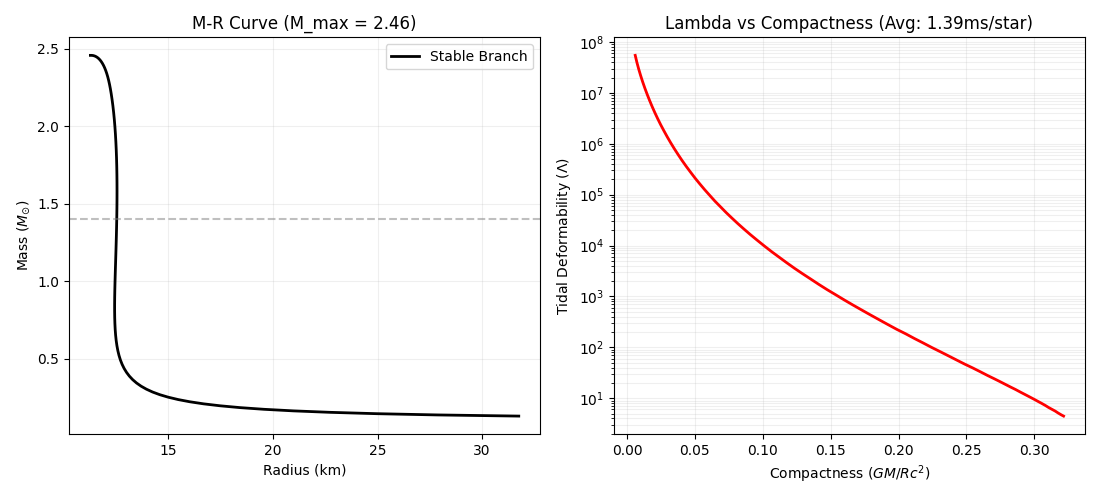

In [28]:
# --- TEST AND BENCHMARK ---
theta = [34.495, 3.446, 3.572, 2.887]
rho_range = np.linspace(14.4, 15.4, 100) 

print(f"--- Timing Test: Solving {len(rho_range)} stars ---")

# Start timing the whole operation
start_total = time.perf_counter()

# This function contains the EoS generation + Fortran Batch Solve
m, r, td = TOV2(rho_range, theta)

end_total = time.perf_counter()

# --- Statistics Calculation ---
total_time = end_total - start_total
avg_star_time = total_time / len(rho_range)

print("-" * 40)
print(f"Total Execution Time (Curve): {total_time:.6f} seconds")
print(f"Average Time per Star:        {avg_star_time * 1000:.4f} milliseconds")
print("-" * 40)

# Calculate 1.4 M_sun benchmarks
if np.max(m) > 1.4:
    # Note: We use the filtered stable branch from TOV2
    f_r = interp1d(m, r, kind='cubic')
    f_l = interp1d(m, td, kind='cubic')
    r14 = f_r(1.4)
    l14 = f_l(1.4)
    print(f"At 1.4 M_sun: Radius = {r14:.2f} km, Lambda = {l14:.1f}")

# --- PLOTTING ---
plt.figure(figsize=(11, 5))

# Subplot 1: Mass-Radius
plt.subplot(1, 2, 1)
plt.plot(r, m, 'k-', lw=2, label="Stable Branch")
plt.axhline(1.4, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Radius (km)')
plt.ylabel(r'Mass ($M_{\odot}$)')
plt.title(f'M-R Curve (M_max = {np.max(m):.2f})')
plt.grid(True, alpha=0.2)
plt.legend()

# Subplot 2: Lambda vs Compactness (M/R)
plt.subplot(1, 2, 2)
# Using mass/radius as compactness (dimensionless requires G/c^2 factor)
compactness = (m * 1.4766) / r 
plt.plot(compactness, td, 'r-', lw=2)
plt.yscale('log')
plt.xlabel('Compactness ($GM/Rc^2$)')
plt.ylabel(r'Tidal Deformability ($\Lambda$)')
plt.title(f'Lambda vs Compactness (Avg: {avg_star_time*1000:.2f}ms/star)')
plt.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()

### <div style= 'color: slateblue'>Create dataset of INPUT and OUTPUT paramters by solving TOV equations with a Piecewise Polytrope

In [9]:
NUM_SAMPLES = 400000 # Number of EOS samples
# Directory to save/load dataset and models 
# If not defined, model will save in current directory.
save_dir_dataset = f"Datasets/{NUM_SAMPLES}samples"

### <div style= 'color: orange'> PyTorch ML pipeline — load data for sanity check

In [10]:
# Load created dataset
data = np.load(os.path.join(save_dir_dataset, f"EOS_dataset_{NUM_SAMPLES}samples.npy"))

# Checking the dataset with added column headers
Column_headers = ['log_rho_c', 'log_p', 'Gamma1', 'Gamma2', 'Gamma3',
                  'Mass_Msun', 'Radius_km', 'TD']
df = pd.DataFrame(data, columns=Column_headers)

# df.head()       # Show first 5 values in each column
df.describe() # Max and min values for each column

# Radius should be within 6 and 24km
# Tidal deformability must be logged

,log_rho_c,log_p,Gamma1,Gamma2,Gamma3,Mass_Msun,Radius_km,TD
count,313204.000000,313204.000000,313204.000000,313204.000000,313204.000000,313204.000000,313204.000000,313204.000000
mean,15.026349,34.230787,3.186065,3.244827,3.205531,1.361733,11.174885,53028.000746
std,0.232651,0.357552,1.032441,1.033178,1.039032,0.799108,2.477591,150669.864586
min,14.500003,33.500007,1.400052,1.400004,1.400022,0.150316,6.153001,0.366197
25%,14.849202,33.948744,2.288948,2.361345,2.304534,0.624121,9.516001,10.007676
50%,15.044499,34.263051,3.170591,3.264420,3.209259,1.277025,10.788001,348.383411
75%,15.223301,34.536595,4.079704,4.140514,4.106054,2.054865,12.287251,13118.709902
max,15.399997,34.799998,4.999995,4.999995,4.999993,3.287210,24.999001,999915.422706


### <div style= 'color: orange'> PyTorch ML pipeline — prepare data

In [11]:
# Set device and batch size for training 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
BATCH_SIZE = 256
save_dir_outputs = f"Outputs/{NUM_SAMPLES}samples"

# ==========================================================
# 1. Split into training and validation sets (80 / 20)
# ==========================================================
split_idx = int(0.8 * len(data))
train_data = data[:split_idx]
val_data = data[split_idx:]

# ==========================================================
# 2. Convert to Tensor
# ==========================================================
# Inputs: Cols 0 to 4 (5 features: log_rho_c, log_p, Gamma1, Gamma2, Gamma3)
# Output: Col 5 - 7 (Mass, Radius, Tidal Deformability)
X_eos_train = torch.tensor(train_data[:, :5], dtype=torch.float32)  # Training Input
y_eos_train = torch.tensor(train_data[:, 5:8], dtype=torch.float32) # Training Output

X_eos_val = torch.tensor(val_data[:, :5], dtype=torch.float32)      # Validation Input
y_eos_val = torch.tensor(val_data[:, 5:8], dtype=torch.float32)     # Validation Output

# ==========================================================
# 3. Normalize the all the inputs using Z-score (Pressure is already logged)
# ==========================================================
X_eos_mean = X_eos_train.mean(dim=0, keepdim=True)
X_eos_std = X_eos_train.std(dim=0, keepdim=True)
# Save the normalization statistics to be used later for model testing
os.makedirs(save_dir_outputs, exist_ok=True)
torch.save(X_eos_mean, os.path.join(save_dir_outputs, "X_eos_mean.pt"))
torch.save(X_eos_std, os.path.join(save_dir_outputs, "X_eos_std.pt"))
print("Normalization statistics saved.")
X_train_norm = (X_eos_train - X_eos_mean) / X_eos_std
X_val_norm = (X_eos_val - X_eos_mean) / X_eos_std

# ==========================================================
# 4. Normalize the outputs
# ==========================================================
# 4.1. Separate the outputs (Mass, Radius and TD) from the 
# training and validation datasets
y_mass_train, y_radius_train, y_td_train = y_eos_train[:, 0:1], y_eos_train[:, 1:2], y_eos_train[:, 2:3]
y_mass_val, y_radius_val, y_td_val = y_eos_val[:, 0:1], y_eos_val[:, 1:2], y_eos_val[:, 2:3]

# 4.2. Constant Scaling on Mass (M)
MASS_SCALE = 3.5
y_mass_train_norm = y_mass_train / MASS_SCALE
y_mass_val_norm = y_mass_val / MASS_SCALE

# 4.3. Constant Scaling on Radius (R)
RADIUS_SCALE = 25.0
y_radius_train_norm = y_radius_train / RADIUS_SCALE
y_radius_val_norm = y_radius_val / RADIUS_SCALE

# 4.4. Log Scaling on Tidal Deformability (TD)
y_td_train_norm = torch.log10(y_td_train)
y_td_val_norm = torch.log10(y_td_val)

# 4.5 Recombine Outputs
y_train_norm = torch.cat((y_mass_train_norm, y_radius_train_norm, y_td_train_norm), dim=1)
y_val_norm = torch.cat((y_mass_val_norm, y_radius_val_norm, y_td_val_norm), dim=1)

Using device: cuda
Normalization statistics saved.


### <div style= 'color: orange'> Range of values of the parameters <b>before</b> scaling and normalizing

In [12]:
print("Log Central Density min/max:", np.round(train_data[:, 0].min(), 3), np.round(train_data[:, 0].max(), 3))
print("Log Pressure min/max:", np.round(train_data[:, 1].min(), 3), np.round(train_data[:, 1].max(), 3))
print("Gamma 1 min/max:", np.round(train_data[:, 2].min(), 3), np.round(train_data[:, 2].max(), 3))
print("Gamma 2 min/max:", np.round(train_data[:, 3].min(), 3), np.round(train_data[:, 3].max(), 3))
print("Gamma 3 min/max:", np.round(train_data[:, 4].min(), 3), np.round(train_data[:, 4].max(), 3))
print("")
print("Mass min/max:", np.round(train_data[:, 5].min(), 3), np.round(train_data[:, 5].max(), 3))
print("Radius min/max:", np.round(train_data[:, 6].min(), 3), np.round(train_data[:, 6].max(), 3))
print("Tidal Deformability min/max:", np.round(train_data[:, 7].min(), 3), np.round(train_data[:, 7].max(), 3))

train_data.shape

Log Central Density min/max: 14.5 15.4
Log Pressure min/max: 33.5 34.8
Gamma 1 min/max: 1.4 5.0
Gamma 2 min/max: 1.4 5.0
Gamma 3 min/max: 1.4 5.0

Mass min/max: 0.15 3.287
Radius min/max: 6.153 24.999
Tidal Deformability min/max: 0.366 999845.922


(250563, 8)

### <div style= 'color: orange'> Range of values of the parameters <b>after</b> scaling and normalizing

In [13]:
print("Log Central Density min/max:", np.round(X_train_norm[:, 0].min(), 3), np.round(X_train_norm[:, 0].max(), 3))
print("Log Pressure min/max:", np.round(X_train_norm[:, 1].min(), 3), np.round(X_train_norm[:, 1].max(), 3))
print("Gamma 1 min/max:", np.round(X_train_norm[:, 2].min(), 3), np.round(X_train_norm[:, 2].max(), 3))
print("Gamma 2 min/max:", np.round(X_train_norm[:, 3].min(), 3), np.round(X_train_norm[:, 3].max(), 3))
print("Gamma 3 min/max:", np.round(X_train_norm[:, 4].min(), 3), np.round(X_train_norm[:, 4].max(), 3))
print("")
print("Mass min/max:", np.round(y_train_norm[:, 0].min(), 3), np.round(y_train_norm[:, 0].max(), 3))
print("Radius min/max:", np.round(y_train_norm[:, 1].min(), 3), np.round(y_train_norm[:, 1].max(), 3))
print("Tidal Deformability min/max:", np.round(y_train_norm[:, 2].min(), 3), np.round(y_train_norm[:, 2].max(), 3))

train_data.shape

Log Central Density min/max: tensor(-2.2610) tensor(1.6060)
Log Pressure min/max: tensor(-2.0450) tensor(1.5930)
Gamma 1 min/max: tensor(-1.7300) tensor(1.7580)
Gamma 2 min/max: tensor(-1.7850) tensor(1.6960)
Gamma 3 min/max: tensor(-1.7380) tensor(1.7280)

Mass min/max: tensor(0.0430) tensor(0.9390)
Radius min/max: tensor(0.2460) tensor(1.)
Tidal Deformability min/max: tensor(-0.4360) tensor(6.)


(250563, 8)

### <div style= 'color: Yellow'>Model Definition

In [14]:
# ==========================================================
# Single Residual Network Block
# ==========================================================
class ResNetBlock(nn.Module): # Custom module
    def __init__(self, hidden_dim): # Constructor of the block
        super().__init__() # Used to define the tools used later
        self.fc = nn.Linear(hidden_dim, hidden_dim) # A fully connected layer
        self.act = nn.GELU() # Gaussian Error Linear Unit activation function
    
    def forward(self, x): # Defines how data flows through the block
        out = self.act(self.fc(x))
        return x + out   # Residual connection


# ==========================================================
# Residual Network
# ==========================================================
class PhysicsEmulator(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=512):
        super().__init__()

        # 1. Initial encoding of all inputs (4 EOS params + logp)
        self.input_layer = nn.Linear(input_dim, hidden_dim)

        # 2. Residual blocks
        self.block1 = ResNetBlock(hidden_dim)
        self.block2 = ResNetBlock(hidden_dim)
        self.block3 = ResNetBlock(hidden_dim)
        self.block4 = ResNetBlock(hidden_dim)

        # 3. Output layers
        self.final_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),  # 512 -> 256
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 3)            # 256 -> 3 outputs
        )

    def forward(self, x):

        # 1. Encode full input
        x_hidden = self.input_layer(x)      # 5 -> 512

        # 2. Residual flow
        x_hidden = self.block1(x_hidden)
        x_hidden = self.block2(x_hidden)
        x_hidden = self.block3(x_hidden)
        x_hidden = self.block4(x_hidden)

        # 3. Prediction
        return self.final_layer(x_hidden)

### <div style= 'color: Yellow'> Testing the Model for a grid of Unseen CD + logp + EOS parameters

In [15]:
# ==========================================================
# 1. Configuration and constants
# ==========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_dir_testing = f"Testing/{NUM_SAMPLES}samples"

RADIUS_SCALE = 25.0
MASS_SCALE = 3.5

MODEL_NO = 1

# ==========================================================
# 2. Set ranges for the parameters of the EOS for the curves to be tested.
#    Should be within training range. Values outside the training range would be extrapolation
# ==========================================================
Gamma1_values = [1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8]
Gamma2_values = [1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8]
Gamma3_values = [1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8]

logp_values = [33.6, 33.8, 34.0, 34.2, 34.4, 34.6, 34.8]

logrho_c_array = np.linspace(14.5, 15.4, 100) # sample different central densities <------------------------------------

# Randomly select combinations of (Γ1,Γ2,Γ3,logp)
param_combinations = list(itertools.product(Gamma1_values, Gamma2_values, Gamma3_values, logp_values))
sampled_combinations = random.sample(param_combinations, 1000)  # Number of random combos <------------------------------

# ==========================================================
# 3. Prepare models and Scalars
# ==========================================================
# Load model and call to device
model = PhysicsEmulator().to(DEVICE)
model.load_state_dict(torch.load(os.path.join(save_dir_outputs, "Best_EOS_Model.pth"), map_location=DEVICE))
model.eval()    # Set model in evaluation mode

# Load the means and stds for normalization from training
X_mean = torch.load(os.path.join(save_dir_outputs, "X_eos_mean.pt")).to(DEVICE)
X_std = torch.load(os.path.join(save_dir_outputs, "X_eos_std.pt")).to(DEVICE)

# Initialize lists to store results
predicted_mass = []
predicted_radius = []
predicted_td = []
original_mass = []
original_radius = []
original_td = []


### <div style= 'color: Yellow'> Testing the Model for a grid of Unseen CD + logp + EOS parameters using TOV-2

#### Timing the TOV solver against the Model prediction for an entire stellar sequence
i.e. Time required to compute an entire M–R curve for one EOS.

In [ ]:
# ==========================================================
# Reproducibility
# ==========================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ==========================================================
# Define Benchmark
# ==========================================================
def benchmark(model, sampled_combinations, logrho_c_array,
              X_mean, X_std, DEVICE,
              MASS_SCALE, RADIUS_SCALE):

    tov_total = 0.0
    model_total = 0.0
    N = len(logrho_c_array)

    for (Gamma1, Gamma2, Gamma3, logp) in sampled_combinations:

        # --- TOV2 Timing ---
        # Ensure TOV2 is the vectorized version we just optimized
        start_tov = time.perf_counter()
        _ = TOV2(logrho_c_array, [logp, Gamma1, Gamma2, Gamma3])
        tov_total += time.perf_counter() - start_tov

        # --- Batched Neural Emulator ---
        start_model = time.perf_counter()

        x = torch.tensor(
            np.column_stack([
                logrho_c_array,
                np.full(N, logp),
                np.full(N, Gamma1),
                np.full(N, Gamma2),
                np.full(N, Gamma3)
            ]),
            dtype=torch.float32
        ).to(DEVICE)

        x_norm = (x - X_mean) / X_std

        with torch.no_grad():
            pred = model(x_norm)

        # CRITICAL: Ensures GPU finished before stopping clock
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        model_total += time.perf_counter() - start_model

    n_curves = len(sampled_combinations)
    tov_avg = tov_total / n_curves
    model_avg = model_total / n_curves
    return {
        "tov_avg": tov_avg,
        "model_avg": model_avg,
        "speedup": tov_avg / model_avg
    }

MEAN Benchmarking

In [ ]:
# ==========================================================
# Run Multiple trials
# ==========================================================
N_RUNS = 3
results = []

for i in range(N_RUNS):
    res = benchmark(
        model,
        sampled_combinations,
        logrho_c_array,
        X_mean,
        X_std,
        DEVICE,
        MASS_SCALE,
        RADIUS_SCALE
    )
    results.append(res)

# ==========================================================
# Compute averaged benchmark
# ==========================================================
tov_avg = np.mean([r["tov_avg"] for r in results])
model_avg = np.mean([r["model_avg"] for r in results])
speedup = tov_avg / model_avg

print("\n================ Benchmark Results ================\n")

print(f"Number of EOS tested: {len(sampled_combinations)}")
print(f"Central density samples per curve: {len(logrho_c_array)}\n")

print(f"Average TOV curve time:   {tov_avg:.4f} s")
print(f"Average Model curve time: {model_avg:.6f} s")

print(f"\nSpeedup factor: {speedup:.1f}x faster")

MEDIAN Benchmarking

In [17]:
# ==========================================================
# Run Benchmark with Warm-up and Median Statistics
# ==========================================================
N_RUNS = 3  # Increased slightly for better median stability
tov_avgs = []
model_avgs = []
speedups = []

print("Starting Benchmark...")

# 1. WARM-UP PHASE
# We run it once and ignore the results to "wake up" the hardware
# and initialize CUDA kernels/Python caches.
_ = benchmark(
    model, sampled_combinations, logrho_c_array,
    X_mean, X_std, DEVICE, MASS_SCALE, RADIUS_SCALE
)
print("Warm-up complete. Starting timed trials...")

# 2. TIMED TRIALS
for i in range(N_RUNS):
    res = benchmark(
        model,
        sampled_combinations,
        logrho_c_array,
        X_mean,
        X_std,
        DEVICE,
        MASS_SCALE,
        RADIUS_SCALE
    )
    
    tov_avgs.append(res["tov_avg"])
    model_avgs.append(res["model_avg"])
    speedups.append(res["speedup"])
    
    print(f"  Run {i+1}/{N_RUNS} complete (Speedup: {res['speedup']:.1f}x)")

# 3. COMPUTE MEDIAN STATISTICS
# Median is robust against "spikes" caused by background OS tasks
tov_median = np.median(tov_avgs)
model_median = np.median(model_avgs)
speedup_median = np.median(speedups)

# Optional: Calculate Standard Deviation to see how "noisy" your system is
speedup_std = np.std(speedups)

# ==========================================================
# Final Results Printout
# ==========================================================
print("\n" + "="*20 + " Final Benchmark Results " + "="*20)
print(f"Number of EOS tested: {len(sampled_combinations)}")
print(f"Samples per curve:    {len(logrho_c_array)}")
print(f"Number of trials:     {N_RUNS} (after 1 warm-up)")
print("-" * 65)

print(f"Median TOV curve time:   {tov_median:.4f} s")
print(f"Median Model curve time: {model_median:.6f} s")
print(f"\n---> Speedup Factor: {speedup_median:.1f}x ± {speedup_std:.1f}x faster")
print("=" * 65)

Starting Benchmark...
Warm-up complete. Starting timed trials...
  Run 1/3 complete (Speedup: 167.8x)
  Run 2/3 complete (Speedup: 120.9x)
  Run 3/3 complete (Speedup: 132.8x)

==================== Final Benchmark Results ====================
Number of EOS tested: 1000
Samples per curve:    100
Number of trials:     3 (after 1 warm-up)
-----------------------------------------------------------------
Median TOV curve time:   0.6485 s
Median Model curve time: 0.004883 s

---> Speedup Factor: 132.8x ± 19.9x faster
